In [12]:
#加载数据集
import numpy as np
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target
RANDOM_STATE = 42

print("X.shape =", X.shape)
print("y.shape =", y.shape)
print("np.unique(y) = ", np.unique(y, return_counts=True))

X.shape = (569, 30)
y.shape = (569,)
np.unique(y) =  (array([0, 1]), array([212, 357]))


In [13]:
#划分数据集
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print("X_train.shape = ", X_train.shape)
print("X_val.shape = ", X_val.shape)
print("X_test.shape = ", X_test.shape)
print("y_train.shape = ", y_train.shape)
print("y_val.shape = ", y_val.shape)
print("y_test.shape = ", y_test.shape)

def value_counts(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f"{name}:")
    for label, count in zip(unique, counts):
        p = count/total * 100
        print(f"  类别 {label} ({data.target_names[label]}): {count} 样本 ({p:.1f}%)")

value_counts(y_train, "train")
value_counts(y_val, "val")
value_counts(y_test, "test")

X_train.shape =  (341, 30)
X_val.shape =  (114, 30)
X_test.shape =  (114, 30)
y_train.shape =  (341,)
y_val.shape =  (114,)
y_test.shape =  (114,)
train:
  类别 0 (malignant): 127 样本 (37.2%)
  类别 1 (benign): 214 样本 (62.8%)
val:
  类别 0 (malignant): 42 样本 (36.8%)
  类别 1 (benign): 72 样本 (63.2%)
test:
  类别 0 (malignant): 43 样本 (37.7%)
  类别 1 (benign): 71 样本 (62.3%)


In [14]:
#划分模型
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

log_reg.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)

#计算验证集上性能数据
y_val_pred_log = log_reg.predict(X_val)
y_val_pred_tree = decision_tree.predict(X_val)

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name} 在验证集上的表现：")
    print(f"  准确率 (Accuracy): {accuracy:.4f}")
    print(f"  精确率 (Precision): {precision:.4f}")
    print(f"  召回率 (Recall): {recall:.4f}")
    print(f"  F1分数 (F1-Score): {f1:.4f}")

    return {'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'model_name': model_name}

# 评估两个模型
log_results = evaluate_model(y_val, y_val_pred_log, "逻辑回归")
tree_results = evaluate_model(y_val, y_val_pred_tree, "决策树")

# 根据F1分数选择最佳模型
best_model_name = log_results['model_name'] if log_results['f1'] >= tree_results['f1'] else tree_results['model_name']
best_model = log_reg if log_results['f1'] >= tree_results['f1'] else decision_tree

print(f"根据验证集F1分数，选择的最佳模型是：{best_model_name}")
print(f"最佳F1分数: {max(log_results['f1'], tree_results['f1']):.4f}")


逻辑回归 在验证集上的表现：
  准确率 (Accuracy): 0.9649
  精确率 (Precision): 0.9595
  召回率 (Recall): 0.9861
  F1分数 (F1-Score): 0.9726

决策树 在验证集上的表现：
  准确率 (Accuracy): 0.9649
  精确率 (Precision): 0.9722
  召回率 (Recall): 0.9722
  F1分数 (F1-Score): 0.9722
根据验证集F1分数，选择的最佳模型是：逻辑回归
最佳F1分数: 0.9726


混淆矩阵： [[38  5]
 [ 1 70]]


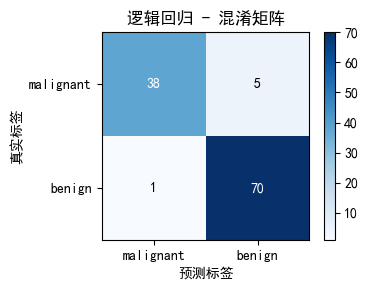


分类报告：
              precision    recall  f1-score   support

   malignant       0.97      0.88      0.93        43
      benign       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [15]:
# 测试集预测
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import pyplot as plt

y_test_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)
print("混淆矩阵：", cm)

# 可视化混淆矩阵
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.figure(figsize=(4, 3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'{best_model_name} - 混淆矩阵')
plt.colorbar()
tick_marks = np.arange(len(data.target_names))
plt.xticks(tick_marks, data.target_names)
plt.yticks(tick_marks, data.target_names)

# 添加数字标签
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.tight_layout()
plt.show()

# 分类报告
print("\n分类报告：")
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

ROC-AUC 分数: 0.9895


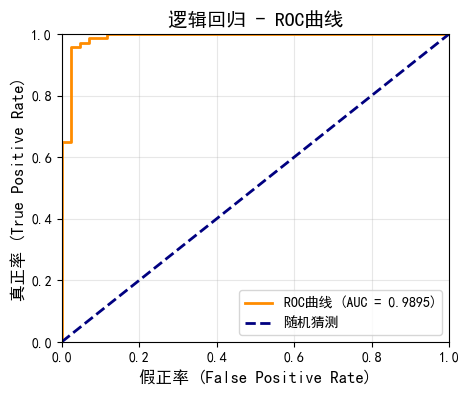


不同阈值的效果比较：

阈值 = 0.5：
  准确率: 0.9474
  精确率: 0.9333
  召回率: 0.9859
  F1分数: 0.9589

阈值 = 0.3：
  准确率: 0.9386
  精确率: 0.9103
  召回率: 1.0000
  F1分数: 0.9530

阈值 = 0.7：
  准确率: 0.9649
  精确率: 0.9718
  召回率: 0.9718
  F1分数: 0.9718


In [16]:
#(a)计算ROC-AUC分数
from sklearn.metrics import roc_auc_score, roc_curve

y_score = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_score)
print(f"ROC-AUC 分数: {roc_auc:.4f}")

#(b)绘制ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_score)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC曲线 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('假正率 (False Positive Rate)', fontsize=12)
plt.ylabel('真正率 (True Positive Rate)', fontsize=12)
plt.title(f'{best_model_name} - ROC曲线', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

#(c)不同阈值的效果比较
print("\n不同阈值的效果比较：")

# 阈值0.5
y_pred_05 = (y_score >= 0.5).astype(int)
print(f"\n阈值 = 0.5：")
print(f"  准确率: {accuracy_score(y_test, y_pred_05):.4f}")
print(f"  精确率: {precision_score(y_test, y_pred_05):.4f}")
print(f"  召回率: {recall_score(y_test, y_pred_05):.4f}")
print(f"  F1分数: {f1_score(y_test, y_pred_05):.4f}")

# 阈值0.3
y_pred_03 = (y_score >= 0.3).astype(int)
print(f"\n阈值 = 0.3：")
print(f"  准确率: {accuracy_score(y_test, y_pred_03):.4f}")
print(f"  精确率: {precision_score(y_test, y_pred_03):.4f}")
print(f"  召回率: {recall_score(y_test, y_pred_03):.4f}")
print(f"  F1分数: {f1_score(y_test, y_pred_03):.4f}")

# 阈值0.7
y_pred_07 = (y_score >= 0.7).astype(int)
print(f"\n阈值 = 0.7：")
print(f"  准确率: {accuracy_score(y_test, y_pred_07):.4f}")
print(f"  精确率: {precision_score(y_test, y_pred_07):.4f}")
print(f"  召回率: {recall_score(y_test, y_pred_07):.4f}")
print(f"  F1分数: {f1_score(y_test, y_pred_07):.4f}")